In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

<Axes: >

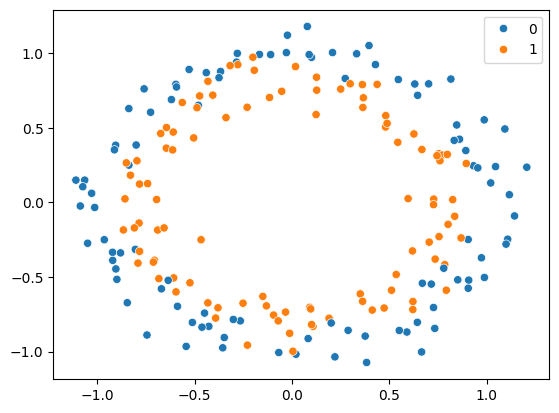

In [9]:
X,y = make_circles(n_samples=200,noise=0.1,random_state=1)
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=2)
model = Sequential()
model.add(Dense(256,activation='relu',input_dim = 2))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])
history = model.fit(X_train,y_train,validation_data =(X_test,y_test),epochs=3500,verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


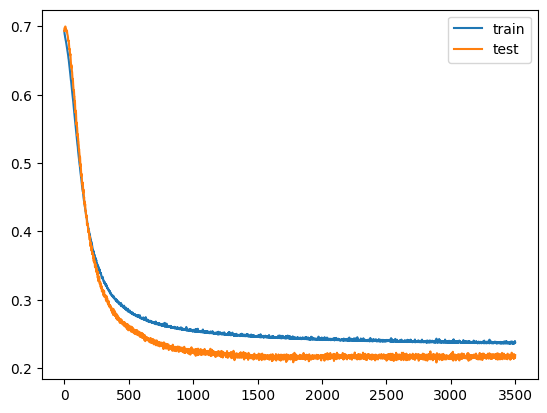

In [11]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

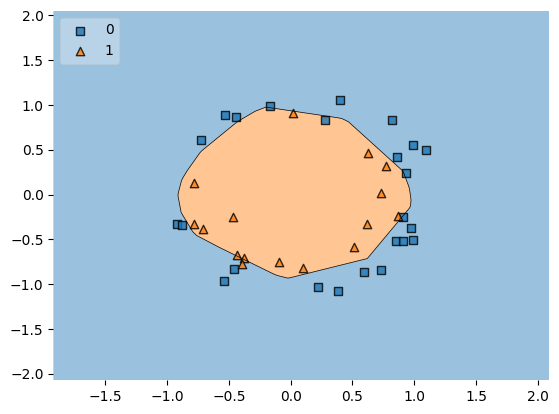

In [12]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)

## Early Stopping

In [19]:
model = Sequential()
model.add(Dense(256,activation='relu',input_dim = 2))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

https://keras.io/api/callbacks/early_stopping/

In [21]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500,callbacks=callback)

Epoch 1/3500


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.5000 - loss: 0.6970 - val_accuracy: 0.3750 - val_loss: 0.7128
Epoch 2/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5375 - loss: 0.6944 - val_accuracy: 0.3250 - val_loss: 0.7104
Epoch 3/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5562 - loss: 0.6925 - val_accuracy: 0.3000 - val_loss: 0.7081
Epoch 4/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5500 - loss: 0.6917 - val_accuracy: 0.3000 - val_loss: 0.7068
Epoch 5/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5375 - loss: 0.6899 - val_accuracy: 0.3250 - val_loss: 0.7050
Epoch 6/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5437 - loss: 0.6888 - val_accuracy: 0.3000 - val_loss: 0.7046
Epoch 7/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5312 - loss: 0.6884 - val_accuracy: 0.3000 - val_loss: 0.7045
Epoch 8/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5250 - loss: 0.6869 - val_accuracy: 0.3250 - val_loss: 0.7

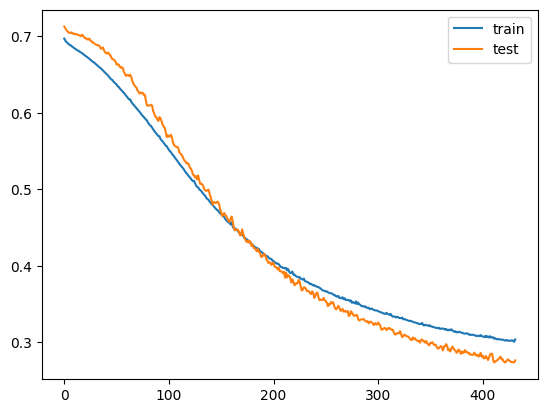

In [22]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

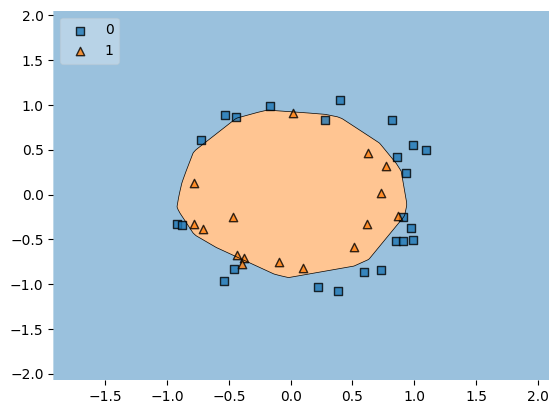

In [23]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)